In [1]:
# Cell 1: Pipeline Pipeline and Model Initialization
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Add project root to python path
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from src.dataset import get_data_loaders
from src.models import build_baseline_cnn
from src.trainer import compile_and_get_callbacks

# 1. Load Data
train_ds, val_ds, _ = get_data_loaders()

# 2. Build Model
model = build_baseline_cnn()

# 3. Compile and fetch monitoring tools
callbacks = compile_and_get_callbacks(model, learning_rate=0.001)

Initializing Data Pipelines...
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.


c:\Users\indra\miniconda3\envs\ganav\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model compiled. Checkpoints will be saved to: c:\Users\indra\OneDrive\Pictures\DeepTrain\DeepTrain\outputs\checkpoints\best_baseline_model.keras


In [2]:
# Cell 2: Execute Model Training
EPOCHS = 5

print("Starting training loop...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
print("Training phase complete!")

Starting training loop...
Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.5044 - loss: 1.2567
Epoch 1: val_loss improved from None to 0.79978, saving model to c:\Users\indra\OneDrive\Pictures\DeepTrain\DeepTrain\outputs\checkpoints\best_baseline_model.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 157s 411ms/step - accuracy: 0.5888 - loss: 1.0655 - val_accuracy: 0.6914 - val_loss: 0.7998
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.6777 - loss: 0.8546
Epoch 2: val_loss improved from 0.79978 to 0.70228, saving model to c:\Users\indra\OneDrive\Pictures\DeepTrain\DeepTrain\outputs\checkpoints\best_baseline_model.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 174s 495ms/step - accuracy: 0.6978 - loss: 0.8156 - val_accuracy: 0.7441 - val_loss: 0.7023
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.7587 - loss: 0.6687
Epoch 3: val_loss improved from 0.70228 to 0.59059, saving model to c:\Users\indra\OneDrive\Pictures\DeepTrain\DeepTrain\outputs\checkpoints

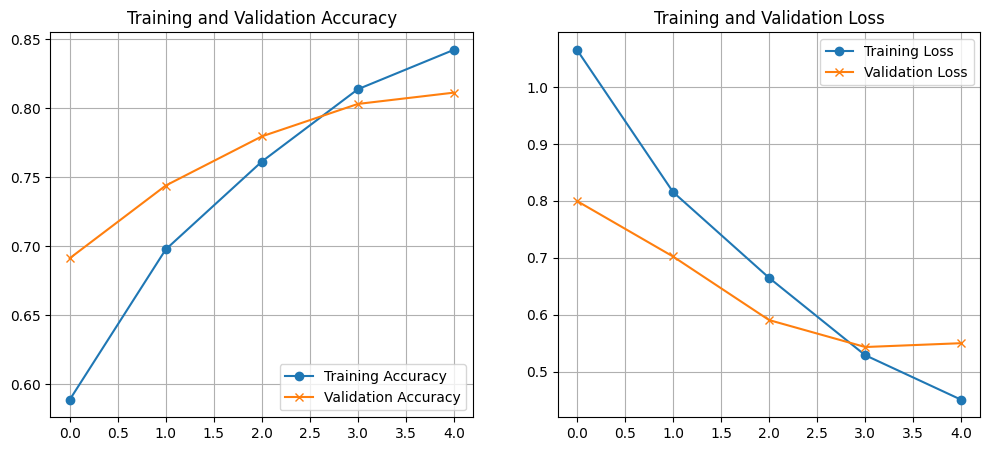

In [3]:
# Cell 3: Plotting Performance Dynamics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True)

plt.show()